## Set Operations

In [16]:
setA = {1,2,3}
setB = {1,2,4,5}

print(setA)
print(setB)
print(setA.union(setB))     #union: A ∪ B
print(setA.intersection(setB)) #intersection: A ∩ B
print(setA.difference(setB)) #difference: A-B
print(setA.symmetric_difference(setB)) #symmetric difference: AΔB or (A ∪ B) − (A ∩ B)


{1, 2, 3}
{1, 2, 4, 5}
{1, 2, 3, 4, 5}
{1, 2}
{3}
{3, 4, 5}


Straight math-to-Python mapping: `union` = A ∪ B (everything in either), `intersection` = A ∩ B (only what's in both), `difference` = A − B (in A but not B - NOT symmetric, `setB.difference(setA)` gives a different answer), `symmetric_difference` = A △ B (in exactly one, never both). Python also lets you write these as operators instead of method calls: `-` for difference, `&` for intersection, `|` for union, `^` for symmetric difference - same result either way.

## Venn Diagram From Real Data

{1, 2, 3}
{1, 2, 4, 5}
{1, 2, 3, 4, 5}
{1, 2}
{3}
{3, 4, 5}


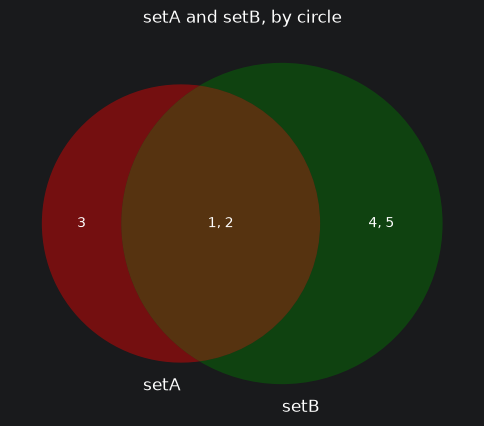

In [17]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

setA = {1, 2, 3}
setB = {1, 2, 4, 5}

print(setA)
print(setB)
print(setA.union(setB))                  # union: A U B
print(setA.intersection(setB))           # intersection: A n B
print(setA.difference(setB))             # difference: A - B
print(setA.symmetric_difference(setB))   # symmetric difference: A^B or (A U B) - (A n B)

# --- now draw it as a Venn diagram ---
only_A = setA - setB
only_B = setB - setA
both = setA & setB


fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([setA, setB], set_labels=('setA', 'setB'), ax=ax)

v.get_label_by_id('10').set_text(', '.join(map(str, sorted(only_A))))
v.get_label_by_id('01').set_text(', '.join(map(str, sorted(only_B))))
v.get_label_by_id('11').set_text(', '.join(map(str, sorted(both))))

plt.title("setA and setB, by circle")
plt.savefig('../sets_full_demo.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

`venn2` (from the separate `matplotlib_venn` library) draws the circles and figures out the overlap sizing automatically from the actual sets. By default each region just shows a *count*, so `get_label_by_id('10')`/`'01'`/`'11'` overwrites those with the real numbers instead - `'10'` = only in the first set, `'01'` = only in the second, `'11'` = in both.

## Venn Diagrams Per Operation

{1, 2, 3}
{1, 2, 4, 5}
{1, 2, 3, 4, 5}
{1, 2}
{3}
{3, 4, 5}


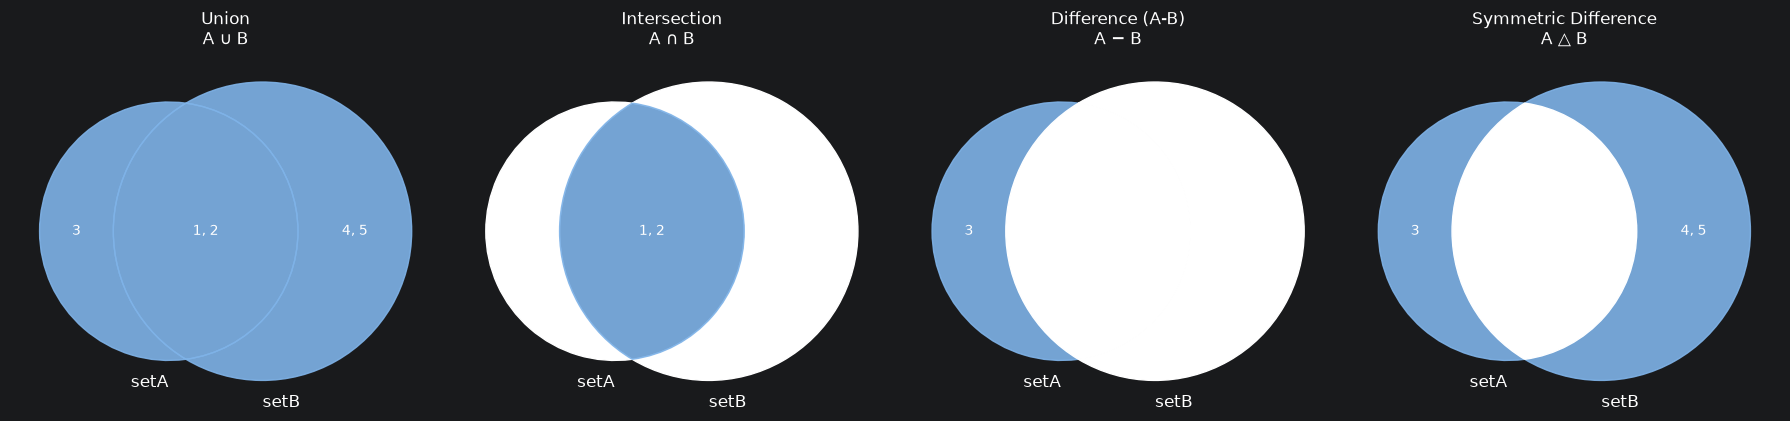

In [18]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

setA = {1, 2, 3}
setB = {1, 2, 4, 5}

print(setA)
print(setB)
print(setA.union(setB))                  # union: A U B
print(setA.intersection(setB))           # intersection: A n B
print(setA.difference(setB))             # difference: A - B
print(setA.symmetric_difference(setB))   # symmetric difference: A^B or (A U B) - (A n B)

only_A = setA - setB
only_B = setB - setA
both = setA & setB

# each entry: title, notation, which regions get colored ('10'=only A, '01'=only B, '11'=overlap)
operations = [
    ("Union", "A ∪ B", {'10', '01', '11'}),
    ("Intersection", "A ∩ B", {'11'}),
    ("Difference (A-B)", "A − B", {'10'}),
    ("Symmetric Difference", "A △ B", {'10', '01'}),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, (title, notation, highlighted) in zip(axes, operations):
    v = venn2([setA, setB], set_labels=('setA', 'setB'), ax=ax)

    # label every region with its real numbers, not a count
    v.get_label_by_id('10').set_text(', '.join(map(str, sorted(only_A))))
    v.get_label_by_id('01').set_text(', '.join(map(str, sorted(only_B))))
    v.get_label_by_id('11').set_text(', '.join(map(str, sorted(both))))

    # color only the region(s) relevant to this operation; fade the rest to white
    for region_id in ('10', '01', '11'):
        patch = v.get_patch_by_id(region_id)
        if patch is None:
            continue
        if region_id in highlighted:
            patch.set_color('#7FB3E8')
            patch.set_alpha(0.9)
        else:
            patch.set_color('white')
            patch.set_alpha(1)

    ax.set_title(f"{title}\n{notation}", fontsize=12)

plt.tight_layout()
plt.savefig('../sets_operations_venn.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Same `venn2` drawing, done four times in a loop - one per operation - but now `get_patch_by_id(region_id)` grabs the actual circle-segment shape and recolors it: blue if that region belongs to the current operation, white if not. That's the "shaded Venn diagram" picture turned into real code instead of hand-drawn shapes.

## List Intersection

In [22]:
l1 = [11, 5, 13, 21, 2, 3, 18, 4, 12, 19]
l2 = [2, 17, 7, 29, 3, 14, 24, 25, 8, 22]
def getIntersection(l1,l2):
    intersection =set()
    for x in l2:
        if x in l1:
            intersection.add(x)
    return intersection
print(getIntersection(l1,l2))


{2, 3}


`intersection.add(x)` is the set equivalent of `.append()` on a list. Worth noticing: `if x in l1` checks membership in a plain **list**, which scans element-by-element every time - the earlier `get_intersection` version from the set-operations exercises converted the second list into a `set` first specifically to make that check instant instead of a scan. Doesn't matter for ten-element lists like these, but it would for large ones.

## First Non-Duplicate Character

In [20]:
def first_non_duplicate(s):
    # Step 1: count how many times each character appears (same blueprint as `frequency`)
    counts = {} # this is a map!
    for ch in s:
        if ch not in counts:
            counts[ch] = 1
        else:
            counts[ch] += 1

    # Step 2: walk through the string again, IN ORDER, and return the first
    # character whose count is exactly 1
    for ch in s:
        if counts[ch] == 1:
            return ch

    return None   # nothing had a count of 1

print(first_non_duplicate("stress")) #Output: 't'
print(first_non_duplicate("swiss")) #Output: 'w'
print(first_non_duplicate("aabbcc")) #Output: 'none'
print(first_non_duplicate("abcabcde")) #Output: 'd'


t
w
None
d


Same counting blueprint as `frequency` (`counts` is a dict/map - build it in one pass), then a **second** pass walks the string again in its original order and returns the first character whose count is exactly 1. Needs two passes because on the first one you can't yet know whether a character will repeat later - trace `"swiss"` by hand: `counts` ends up `{s: 3, w: 1, i: 1}`, and the second pass hits `w` before `i`, so `w` wins even though both are technically unique.